# ResNet50 + SimCLRv2 Fine-tuning Experiments

Notebook này dùng để chạy fine-tune từ checkpoint SimCLRv2 pretrained, lấy val accuracy, xuất bảng kết quả và vẽ hình phục vụ báo cáo/bài báo.


> Mặc định notebook chạy trên local Windows với project ở `D:\ML3`.
> Nếu project nằm chỗ khác, sửa `PROJECT_DIR` ở cell cấu hình.


In [15]:
from pathlib import Path
import sys, time, math, json, random
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Configuration


In [16]:
PROJECT_DIR = Path(r"D:\ML3")
DATA_ROOT = PROJECT_DIR / "data"
PRETRAIN_CKPT = PROJECT_DIR / "checkpoints_2" / "simclrv2_resnet50_epoch_300.pt"

OUT_ROOT = PROJECT_DIR / "paper_outputs" / "finetune"
FIG_DIR = OUT_ROOT / "figures"
CKPT_ROOT = OUT_ROOT / "checkpoints_2"
TABLE_DIR = OUT_ROOT / "tables"

ARCH = "resnet50"
NUM_CLASSES = 10
IMAGE_SIZE = 96
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

for d in [OUT_ROOT, FIG_DIR, CKPT_ROOT, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

assert PROJECT_DIR.exists(), PROJECT_DIR
assert DATA_ROOT.exists(), DATA_ROOT
assert PRETRAIN_CKPT.exists(), PRETRAIN_CKPT

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_ROOT:", DATA_ROOT)
print("PRETRAIN_CKPT:", PRETRAIN_CKPT)
print("OUT_ROOT:", OUT_ROOT)
print("DEVICE:", DEVICE)


PROJECT_DIR: D:\ML3
DATA_ROOT: D:\ML3\data
PRETRAIN_CKPT: D:\ML3\checkpoints_2\simclrv2_resnet50_epoch_300.pt
OUT_ROOT: D:\ML3\paper_outputs\finetune
DEVICE: cuda


## 2. Utilities


In [17]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)

def save_current_figure(name):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    plt.savefig(png, dpi=300, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)

def plot_line(df, x, y, title, xlabel, ylabel, name, label_col=None):
    plt.figure(figsize=(8, 4.8))
    if label_col is None:
        plt.plot(df[x], df[y], marker="o")
    else:
        for label, g in df.groupby(label_col):
            plt.plot(g[x], g[y], marker="o", label=str(label))
        plt.legend()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    save_current_figure(name)
    plt.show()

def topk_correct(logits, targets, k=5):
    k = min(k, logits.shape[1])
    top = logits.topk(k, dim=1).indices
    return top.eq(targets.view(-1, 1)).any(dim=1).sum().item()

def confusion_matrix_np(y_true, y_pred, n):
    cm = np.zeros((n, n), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm


## 3. Import project code


In [18]:
sys.path.insert(0, str(PROJECT_DIR))

from resnet18 import build_resnet
from ssl_simclr import SimCLR, ProjectionHead, SimCLRFineTuner
from dataset import get_dataloaders

print("Project imports OK")


Project imports OK


## 4. Dataset


In [19]:
train_loader, val_loader = get_dataloaders(
    batch_size=64,
    data_root=str(DATA_ROOT),
    dataset="stl10",
    image_size=IMAGE_SIZE,
    num_workers=0,
    download=False,
    use_cuda=(DEVICE.type == "cuda"),
    distributed=False,
)

class_names = getattr(val_loader.dataset, "classes", [str(i) for i in range(NUM_CLASSES)])

print("Train samples:", len(train_loader.dataset))
print("Val/Test samples:", len(val_loader.dataset))
print("Classes:", class_names)


Train samples: 5000
Val/Test samples: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


## 5. Model builder


In [20]:
def load_pretrained_simclr(pretrain_ckpt, arch="resnet50", num_classes=10, proj_dim=128, proj_hidden_dim=0, proj_layers=3):
    ckpt = torch.load(pretrain_ckpt, map_location="cpu")
    args = ckpt.get("args", {})
    arch = args.get("arch", arch)
    proj_dim = int(args.get("proj_dim", proj_dim))
    proj_layers = int(args.get("proj_layers", proj_layers))

    backbone = build_resnet(arch, num_classes=num_classes)
    feat_dim = getattr(backbone, "feature_dim", 512)
    simclr = SimCLR(
        backbone=backbone,
        feat_dim=feat_dim,
        proj_dim=proj_dim,
        proj_hidden_dim=int(args.get("proj_hidden_dim", 0) or feat_dim),
        proj_layers=proj_layers,
    )

    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    state = {k.replace("module.", "", 1): v for k, v in state.items()}
    msg = simclr.load_state_dict(state, strict=False)
    print("Loaded pretrain:", pretrain_ckpt)
    print("Pretrain epoch:", ckpt.get("epoch"))
    print("Missing:", len(msg.missing_keys), msg.missing_keys[:10])
    print("Unexpected:", len(msg.unexpected_keys), msg.unexpected_keys[:10])
    return simclr, ckpt

def build_finetune_model(include_proj_layers):
    simclr, ckpt = load_pretrained_simclr(PRETRAIN_CKPT, arch=ARCH, num_classes=NUM_CLASSES)
    model = SimCLRFineTuner(
        backbone=simclr.backbone,
        projector=simclr.projector,
        num_classes=NUM_CLASSES,
        include_proj_layers=include_proj_layers,
    )
    return model, ckpt


## 6. Training / evaluation functions


In [21]:
def evaluate(model, loader, device):
    model.eval()
    ce = nn.CrossEntropyLoss(reduction="sum")
    total_loss = 0.0
    total = 0
    top1 = 0
    top5 = 0
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits = model(images)
            loss = ce(logits, targets)

            pred = logits.argmax(dim=1)
            prob = torch.softmax(logits, dim=1)

            bs = targets.numel()
            total += bs
            total_loss += float(loss.item())
            top1 += int((pred == targets).sum().item())
            top5 += int(topk_correct(logits, targets, k=5))

            y_true.append(targets.detach().cpu())
            y_pred.append(pred.detach().cpu())
            y_prob.append(prob.detach().cpu())

    return {
        "loss": total_loss / max(total, 1),
        "top1": 100.0 * top1 / max(total, 1),
        "top5": 100.0 * top5 / max(total, 1),
        "correct": top1,
        "total": total,
        "y_true": torch.cat(y_true).numpy(),
        "y_pred": torch.cat(y_pred).numpy(),
        "y_prob": torch.cat(y_prob).numpy(),
    }

def train_one_epoch(model, loader, optimizer, scaler, device, use_amp=True):
    model.train()
    ce = nn.CrossEntropyLoss()
    total_loss = 0.0
    total = 0
    top1 = 0
    top5 = 0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):
            logits = model(images)
            loss = ce(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = targets.numel()
        total += bs
        total_loss += float(loss.item()) * bs
        pred = logits.argmax(dim=1)
        top1 += int((pred == targets).sum().item())
        top5 += int(topk_correct(logits.detach(), targets, k=5))

    return {
        "loss": total_loss / max(total, 1),
        "top1": 100.0 * top1 / max(total, 1),
        "top5": 100.0 * top5 / max(total, 1),
    }


## 7. Experiment settings


In [22]:
@dataclass
class FineTuneExperiment:
    name: str
    include_proj_layers: int = 0
    lr: float = 0.02
    epochs: int = 120
    batch_size: int = 64
    weight_decay: float = 0.0
    momentum: float = 0.9
    warmup_epochs: int = 0

# Mặc định chạy bản tốt hiện tại. Có thể thêm ft1 để so sánh middle projection head.
EXPERIMENTS = [
    FineTuneExperiment(name="ft0_lr002", include_proj_layers=0, lr=0.02, epochs=120, batch_size=64, weight_decay=0.0),
    # FineTuneExperiment(name="ft1_lr002", include_proj_layers=1, lr=0.02, epochs=120, batch_size=64, weight_decay=0.0),
]

for e in EXPERIMENTS:
    print(e)


FineTuneExperiment(name='ft0_lr002', include_proj_layers=0, lr=0.02, epochs=120, batch_size=64, weight_decay=0.0, momentum=0.9, warmup_epochs=0)


## 8. Run fine-tuning


In [23]:
all_histories = []
best_rows = []

for exp in EXPERIMENTS:
    print("\n" + "=" * 80)
    print("Experiment:", exp)
    print("=" * 80)

    seed_everything(SEED)
    train_loader, val_loader = get_dataloaders(
        batch_size=exp.batch_size,
        data_root=str(DATA_ROOT),
        dataset="stl10",
        image_size=IMAGE_SIZE,
        num_workers=0,
        download=False,
        use_cuda=(DEVICE.type == "cuda"),
        distributed=False,
    )

    model, pretrain_info = build_finetune_model(include_proj_layers=exp.include_proj_layers)
    model = model.to(DEVICE)

    optimizer = optim.SGD(model.parameters(), lr=exp.lr, momentum=exp.momentum, weight_decay=exp.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=exp.epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    exp_dir = CKPT_ROOT / exp.name
    exp_dir.mkdir(parents=True, exist_ok=True)

    best_acc = -1.0
    best_ckpt_path = exp_dir / "best.pt"
    history = []

    for epoch in range(1, exp.epochs + 1):
        t0 = time.time()
        train_metrics = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE)
        val_metrics = evaluate(model, val_loader, DEVICE)
        lr_now = optimizer.param_groups[0]["lr"]
        scheduler.step()
        elapsed = time.time() - t0

        row = {
            "experiment": exp.name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_top1": train_metrics["top1"],
            "train_top5": train_metrics["top5"],
            "val_loss": val_metrics["loss"],
            "val_top1": val_metrics["top1"],
            "val_top5": val_metrics["top5"],
            "lr": lr_now,
            "time_sec": elapsed,
            "include_proj_layers": exp.include_proj_layers,
            "weight_decay": exp.weight_decay,
        }
        history.append(row)
        all_histories.append(row)

        print(
            f"{exp.name} | epoch {epoch:03d}/{exp.epochs} | "
            f"train_loss={row['train_loss']:.4f} train_acc={row['train_top1']:.2f}% | "
            f"val_loss={row['val_loss']:.4f} val_acc={row['val_top1']:.2f}% | "
            f"lr={row['lr']:.5g} | time={elapsed:.1f}s"
        )

        if val_metrics["top1"] > best_acc:
            best_acc = val_metrics["top1"]
            torch.save({
                "epoch": epoch,
                "model": model.state_dict(),
                "args": {
                    "arch": ARCH,
                    "num_classes": NUM_CLASSES,
                    "image_size": IMAGE_SIZE,
                    "proj_layers": 3,
                    "proj_dim": 128,
                    "finetune_proj_layers": exp.include_proj_layers,
                    "lr": exp.lr,
                    "weight_decay": exp.weight_decay,
                    "batch_size": exp.batch_size,
                    "pretrain_ckpt": str(PRETRAIN_CKPT),
                },
                "best_acc": best_acc,
                "mode": "finetune",
                "experiment": asdict(exp),
            }, best_ckpt_path)

    df_exp = pd.DataFrame(history)
    df_exp.to_csv(TABLE_DIR / f"{exp.name}_history.csv", index=False)

    best_epoch = int(df_exp.loc[df_exp["val_top1"].idxmax(), "epoch"])
    best_rows.append({
        "experiment": exp.name,
        "best_val_top1": best_acc,
        "best_epoch": best_epoch,
        "include_proj_layers": exp.include_proj_layers,
        "lr": exp.lr,
        "weight_decay": exp.weight_decay,
        "checkpoint": str(best_ckpt_path),
    })

df_history = pd.DataFrame(all_histories)
df_best = pd.DataFrame(best_rows).sort_values("best_val_top1", ascending=False)

df_history.to_csv(TABLE_DIR / "finetune_all_history.csv", index=False)
df_best.to_csv(TABLE_DIR / "finetune_best_summary.csv", index=False)

display(df_best)



Experiment: FineTuneExperiment(name='ft0_lr002', include_proj_layers=0, lr=0.02, epochs=120, batch_size=64, weight_decay=0.0, momentum=0.9, warmup_epochs=0)


C:\Users\DELL\AppData\Local\Temp\ipykernel_508\3344946969.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(pretrain_ckpt, map_location="cpu")


Loaded pretrain: D:\ML3\checkpoints_2\simclrv2_resnet50_epoch_300.pt
Pretrain epoch: 300
Missing: 2 ['backbone.fc.weight', 'backbone.fc.bias']
Unexpected: 0 []


C:\Users\DELL\AppData\Local\Temp\ipykernel_508\2294937164.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
C:\Users\DELL\AppData\Local\Temp\ipykernel_508\780279051.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):


ft0_lr002 | epoch 001/120 | train_loss=2.0483 train_acc=33.62% | val_loss=1.7669 val_acc=31.70% | lr=0.02 | time=10.1s
ft0_lr002 | epoch 002/120 | train_loss=1.7222 train_acc=33.88% | val_loss=1.6805 val_acc=40.05% | lr=0.019997 | time=9.5s
ft0_lr002 | epoch 003/120 | train_loss=1.5456 train_acc=41.30% | val_loss=1.5224 val_acc=44.46% | lr=0.019986 | time=9.5s
ft0_lr002 | epoch 004/120 | train_loss=1.4284 train_acc=47.84% | val_loss=1.4735 val_acc=46.36% | lr=0.019969 | time=9.5s
ft0_lr002 | epoch 005/120 | train_loss=1.3297 train_acc=50.62% | val_loss=1.8579 val_acc=42.50% | lr=0.019945 | time=9.5s
ft0_lr002 | epoch 006/120 | train_loss=1.2257 train_acc=54.62% | val_loss=1.1714 val_acc=56.49% | lr=0.019914 | time=9.5s
ft0_lr002 | epoch 007/120 | train_loss=1.1664 train_acc=57.86% | val_loss=1.1623 val_acc=57.62% | lr=0.019877 | time=9.6s
ft0_lr002 | epoch 008/120 | train_loss=1.0966 train_acc=60.40% | val_loss=1.1833 val_acc=58.21% | lr=0.019833 | time=9.6s
ft0_lr002 | epoch 009/120 |

,experiment,best_val_top1,best_epoch,include_proj_layers,lr,weight_decay,checkpoint
0,ft0_lr002,82.7,113,0,0.02,0.0,D:\ML3\paper_outputs\finetune\checkpoints_2\ft...


## 9. Learning curves


,experiment,epoch,train_loss,train_top1,train_top5,val_loss,val_top1,val_top5,lr,time_sec,include_proj_layers,weight_decay
115,ft0_lr002,116,0.074357,97.62,99.98,0.756147,82.525,98.8250,0.000086,10.410970,0,0.0
116,ft0_lr002,117,0.069920,97.90,99.98,0.749373,82.600,98.9125,0.000055,10.495359,0,0.0
117,ft0_lr002,118,0.072137,97.66,99.98,0.745637,82.475,98.8250,0.000031,10.466176,0,0.0
118,ft0_lr002,119,0.058831,98.04,99.94,0.750339,82.525,98.8500,0.000014,10.547115,0,0.0
119,ft0_lr002,120,0.070890,97.66,99.92,0.762570,82.350,98.8750,0.000003,10.620266,0,0.0


Saved: D:\ML3\paper_outputs\finetune\figures\finetune_train_loss.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_train_loss.pdf


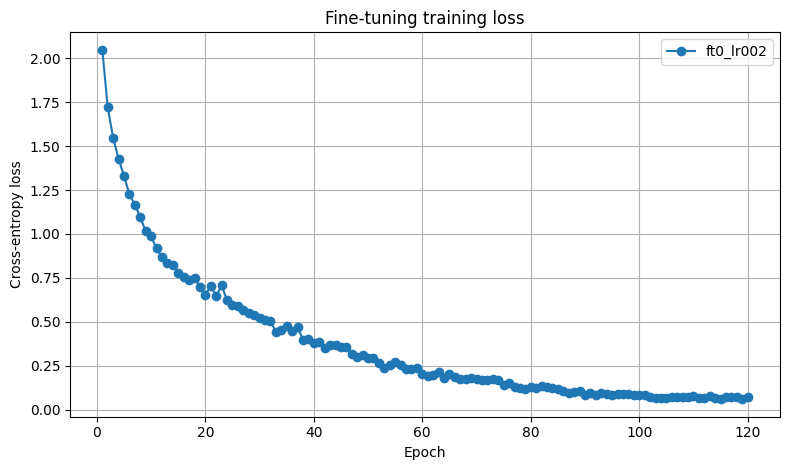

Saved: D:\ML3\paper_outputs\finetune\figures\finetune_val_loss.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_val_loss.pdf


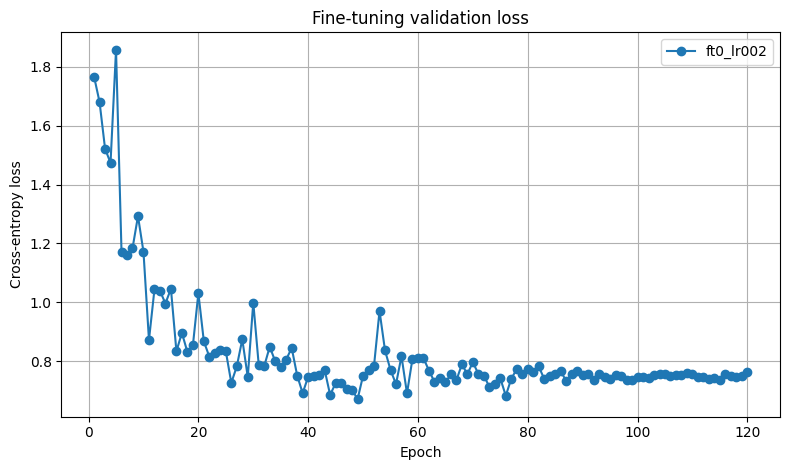

Saved: D:\ML3\paper_outputs\finetune\figures\finetune_train_acc.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_train_acc.pdf


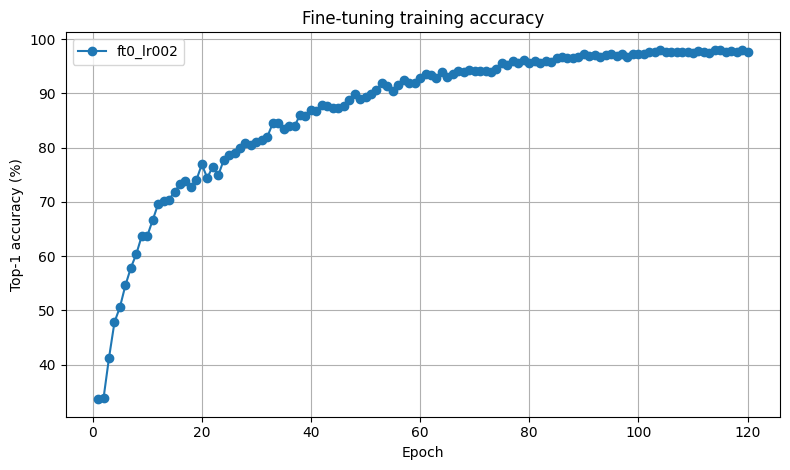

Saved: D:\ML3\paper_outputs\finetune\figures\finetune_val_acc.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_val_acc.pdf


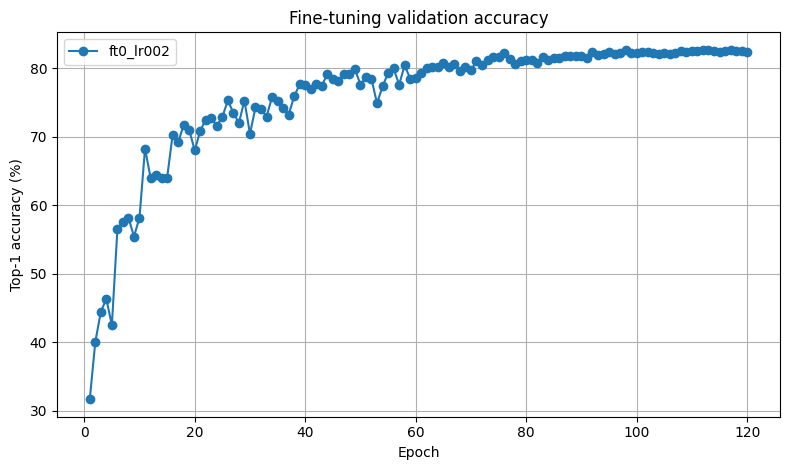

Saved: D:\ML3\paper_outputs\finetune\figures\finetune_lr_schedule.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_lr_schedule.pdf


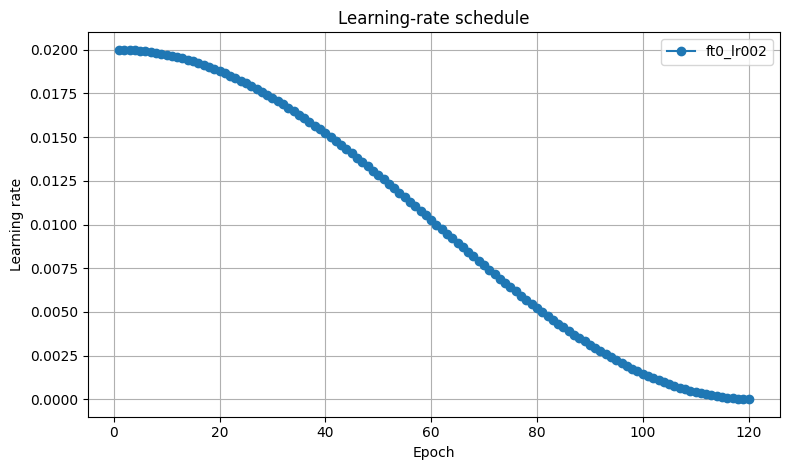

In [24]:
display(df_history.tail())

plot_line(
    df_history, "epoch", "train_loss",
    "Fine-tuning training loss",
    "Epoch", "Cross-entropy loss",
    "finetune_train_loss",
    label_col="experiment",
)

plot_line(
    df_history, "epoch", "val_loss",
    "Fine-tuning validation loss",
    "Epoch", "Cross-entropy loss",
    "finetune_val_loss",
    label_col="experiment",
)

plot_line(
    df_history, "epoch", "train_top1",
    "Fine-tuning training accuracy",
    "Epoch", "Top-1 accuracy (%)",
    "finetune_train_acc",
    label_col="experiment",
)

plot_line(
    df_history, "epoch", "val_top1",
    "Fine-tuning validation accuracy",
    "Epoch", "Top-1 accuracy (%)",
    "finetune_val_acc",
    label_col="experiment",
)

plot_line(
    df_history, "epoch", "lr",
    "Learning-rate schedule",
    "Epoch", "Learning rate",
    "finetune_lr_schedule",
    label_col="experiment",
)


## 10. Best model evaluation details


In [25]:
best_row = df_best.iloc[0]
best_ckpt = Path(best_row["checkpoint"])
print("Best checkpoint:", best_ckpt)
print(best_row.to_string())

best_payload = torch.load(best_ckpt, map_location="cpu")
best_args = best_payload["args"]
best_model, _ = build_finetune_model(include_proj_layers=int(best_args["finetune_proj_layers"]))
best_model.load_state_dict(best_payload["model"], strict=True)
best_model = best_model.to(DEVICE).eval()

_, val_loader = get_dataloaders(
    batch_size=128,
    data_root=str(DATA_ROOT),
    dataset="stl10",
    image_size=IMAGE_SIZE,
    num_workers=0,
    download=False,
    use_cuda=(DEVICE.type == "cuda"),
    distributed=False,
)
best_eval = evaluate(best_model, val_loader, DEVICE)

print("Best val top-1:", f"{best_eval['top1']:.2f}%")
print("Best val top-5:", f"{best_eval['top5']:.2f}%")
print("Val loss:", f"{best_eval['loss']:.4f}")
print("Correct:", f"{best_eval['correct']}/{best_eval['total']}")


Best checkpoint: D:\ML3\paper_outputs\finetune\checkpoints_2\ft0_lr002\best.pt
experiment                                                     ft0_lr002
best_val_top1                                                       82.7
best_epoch                                                           113
include_proj_layers                                                    0
lr                                                                  0.02
weight_decay                                                         0.0
checkpoint             D:\ML3\paper_outputs\finetune\checkpoints_2\ft...


C:\Users\DELL\AppData\Local\Temp\ipykernel_508\2156708531.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_payload = torch.load(best_ckpt, map_location="cpu")
C:\Use

Loaded pretrain: D:\ML3\checkpoints_2\simclrv2_resnet50_epoch_300.pt
Pretrain epoch: 300
Missing: 2 ['backbone.fc.weight', 'backbone.fc.bias']
Unexpected: 0 []
Best val top-1: 82.70%
Best val top-5: 98.84%
Val loss: 0.7398
Correct: 6616/8000


## 11. Confusion matrix and per-class accuracy


Saved: D:\ML3\paper_outputs\finetune\figures\finetune_confusion_matrix.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_confusion_matrix.pdf


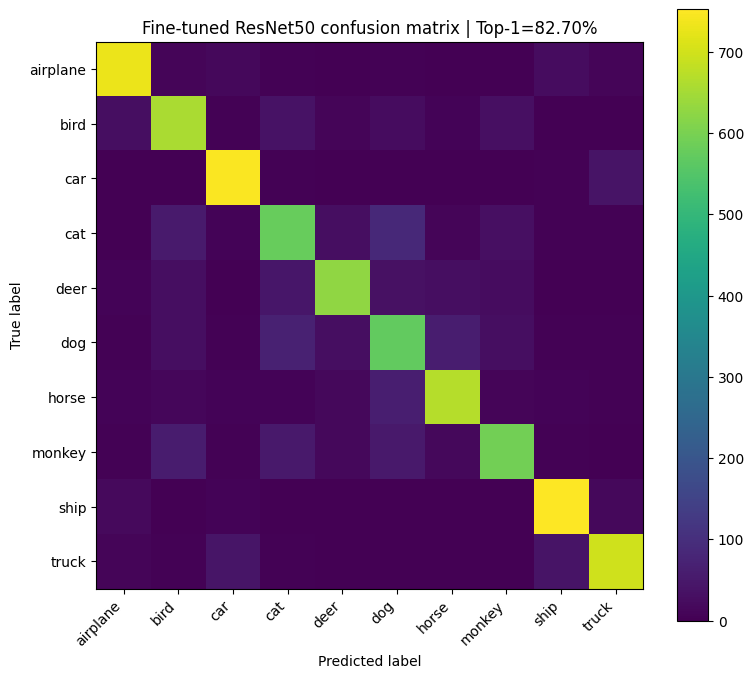

Saved: D:\ML3\paper_outputs\finetune\figures\finetune_confusion_matrix_normalized.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_confusion_matrix_normalized.pdf


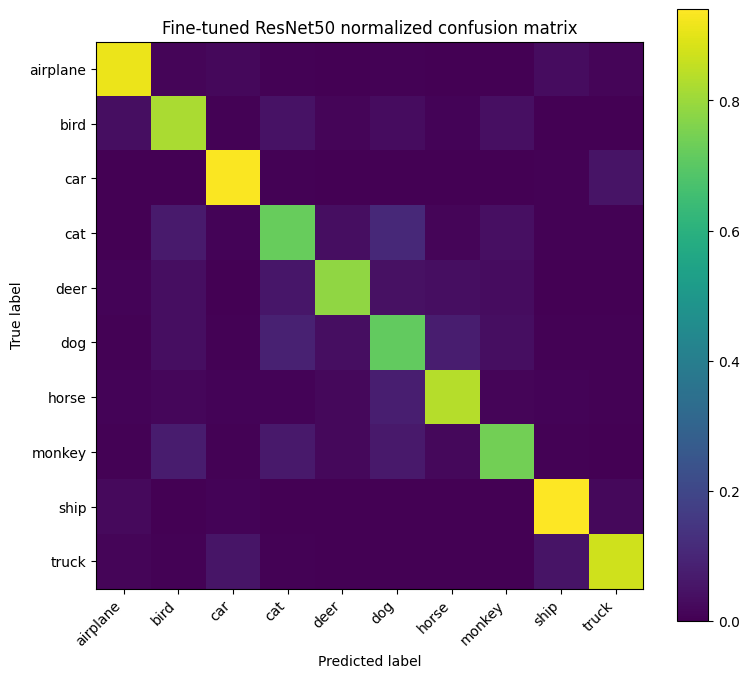

,class,correct,total,accuracy
8,ship,752,800,0.94000
2,car,747,800,0.93375
0,airplane,729,800,0.91125
9,truck,697,800,0.87125
6,horse,667,800,0.83375
1,bird,656,800,0.82000
4,deer,628,800,0.78500
7,monkey,593,800,0.74125
3,cat,577,800,0.72125
5,dog,570,800,0.71250


Saved: D:\ML3\paper_outputs\finetune\figures\finetune_per_class_accuracy.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_per_class_accuracy.pdf


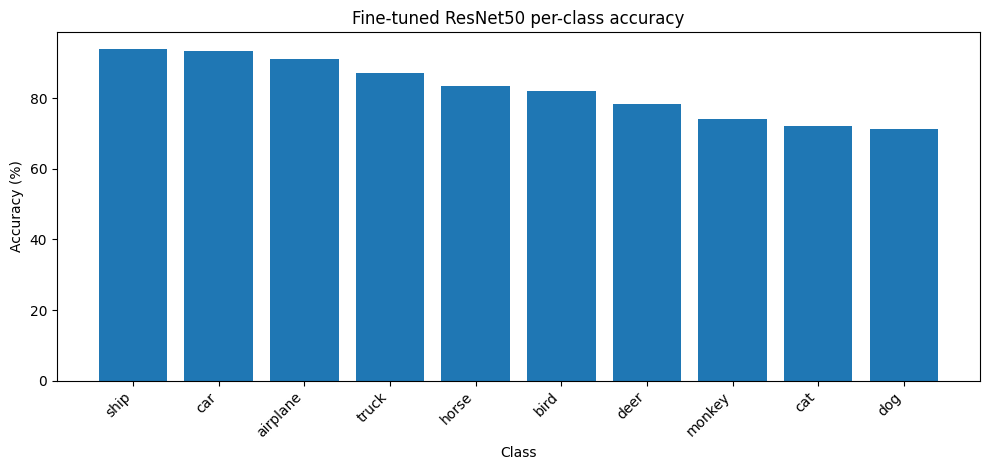

In [26]:
cm = confusion_matrix_np(best_eval["y_true"], best_eval["y_pred"], NUM_CLASSES)

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title(f"Fine-tuned ResNet50 confusion matrix | Top-1={best_eval['top1']:.2f}%")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar()
plt.tight_layout()
save_current_figure("finetune_confusion_matrix")
plt.show()

cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
plt.figure(figsize=(8, 7))
plt.imshow(cm_norm)
plt.title("Fine-tuned ResNet50 normalized confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar()
plt.tight_layout()
save_current_figure("finetune_confusion_matrix_normalized")
plt.show()

per_class = pd.DataFrame({
    "class": class_names,
    "correct": np.diag(cm),
    "total": cm.sum(axis=1),
})
per_class["accuracy"] = per_class["correct"] / per_class["total"].clip(lower=1)
per_class = per_class.sort_values("accuracy", ascending=False)
per_class.to_csv(TABLE_DIR / "finetune_per_class_accuracy.csv", index=False)

display(per_class)

plt.figure(figsize=(10, 4.8))
plt.bar(per_class["class"], per_class["accuracy"] * 100)
plt.title("Fine-tuned ResNet50 per-class accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_current_figure("finetune_per_class_accuracy")
plt.show()


## 12. Prediction confidence analysis


Saved: D:\ML3\paper_outputs\finetune\figures\finetune_confidence_histogram.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_confidence_histogram.pdf


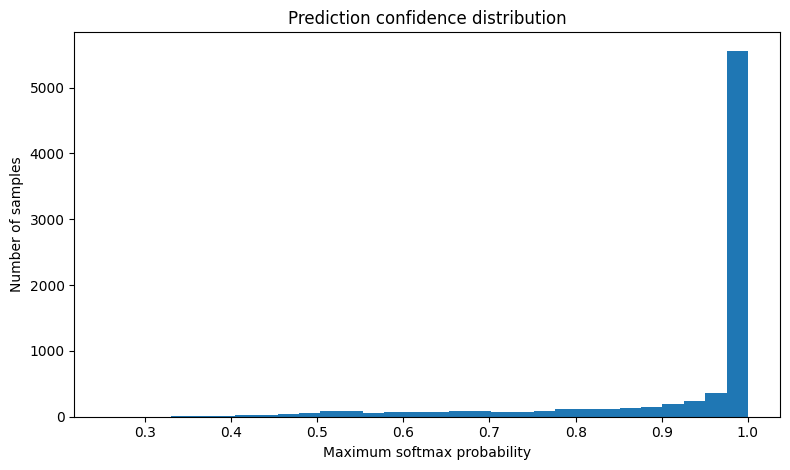

,true_class,error
0,dog,0.28750
1,cat,0.27875
2,monkey,0.25875
3,deer,0.21500
4,bird,0.18000
5,horse,0.16625
6,truck,0.12875
7,airplane,0.08875
8,car,0.06625
9,ship,0.06000


Saved: D:\ML3\paper_outputs\finetune\figures\finetune_error_rate_by_class.png
Saved: D:\ML3\paper_outputs\finetune\figures\finetune_error_rate_by_class.pdf


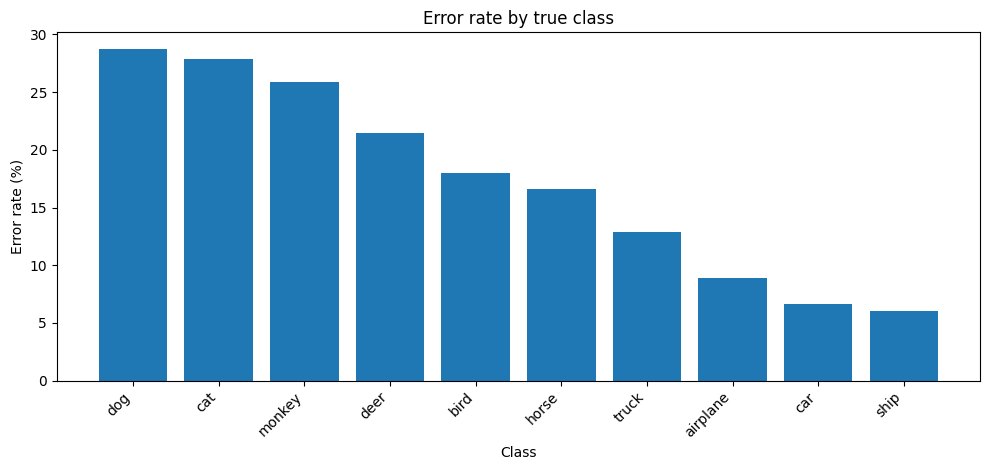

In [27]:
conf = best_eval["y_prob"].max(axis=1)
correct_mask = best_eval["y_true"] == best_eval["y_pred"]

df_pred = pd.DataFrame({
    "true": best_eval["y_true"],
    "pred": best_eval["y_pred"],
    "true_class": [class_names[i] for i in best_eval["y_true"]],
    "pred_class": [class_names[i] for i in best_eval["y_pred"]],
    "confidence": conf,
    "correct": correct_mask,
})
df_pred.to_csv(TABLE_DIR / "finetune_predictions.csv", index=False)

plt.figure(figsize=(8, 4.8))
plt.hist(df_pred["confidence"], bins=30)
plt.title("Prediction confidence distribution")
plt.xlabel("Maximum softmax probability")
plt.ylabel("Number of samples")
plt.tight_layout()
save_current_figure("finetune_confidence_histogram")
plt.show()

error_by_class = (
    df_pred.assign(error=~df_pred["correct"])
    .groupby("true_class")["error"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
display(error_by_class)

plt.figure(figsize=(10, 4.8))
plt.bar(error_by_class["true_class"], error_by_class["error"] * 100)
plt.title("Error rate by true class")
plt.xlabel("Class")
plt.ylabel("Error rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_current_figure("finetune_error_rate_by_class")
plt.show()


## 13. Paper-ready summary


In [28]:
summary = pd.DataFrame([{
    "method": "SimCLRv2 pretrain + fine-tune",
    "backbone": ARCH,
    "pretrain_checkpoint": str(PRETRAIN_CKPT.name),
    "best_experiment": best_row["experiment"],
    "finetune_proj_layers": int(best_row["include_proj_layers"]),
    "lr": float(best_row["lr"]),
    "weight_decay": float(best_row["weight_decay"]),
    "best_epoch": int(best_row["best_epoch"]),
    "top1_acc": float(best_eval["top1"]),
    "top5_acc": float(best_eval["top5"]),
    "val_loss": float(best_eval["loss"]),
}])
summary.to_csv(TABLE_DIR / "finetune_paper_summary.csv", index=False)
display(summary)
print("All outputs saved in:", OUT_ROOT)


,method,backbone,pretrain_checkpoint,best_experiment,finetune_proj_layers,lr,weight_decay,best_epoch,top1_acc,top5_acc,val_loss
0,SimCLRv2 pretrain + fine-tune,resnet50,simclrv2_resnet50_epoch_300.pt,ft0_lr002,0,0.02,0.0,113,82.7,98.8375,0.739764


All outputs saved in: D:\ML3\paper_outputs\finetune
